In [1]:
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import random
from shapely.geometry import LineString, Polygon, Point, MultiPolygon
import numpy as np
import networkx as nx
from itertools import combinations
import osmnx as ox
import tobler
import rasterio
from rasterio.mask import mask
from pathlib import Path

In [2]:
def Create_grid_1(res, prompt_1, proj_crs, prompt_2=False, prompt_3=False, return_points=False):
    # Start with prompt_1
    prompt_1_gdf = ox.geocode_to_gdf(prompt_1)
    merged_geom = prompt_1_gdf.union_all()

    # Add prompt_2 if provided
    if prompt_2:
        prompt_2_gdf = ox.geocode_to_gdf(prompt_2)
        merged_geom = merged_geom.union(prompt_2_gdf.union_all())

    # Add prompt_3 if provided
    if prompt_3:
        prompt_3_gdf = ox.geocode_to_gdf(prompt_3)
        merged_geom = merged_geom.union(prompt_3_gdf.union_all())

    # Back into GeoDataFrame and project
    merged = gpd.GeoDataFrame(
        {"name": ["merged_area"]},
        geometry=[merged_geom],
        crs=prompt_1_gdf.crs
    ).to_crs(proj_crs)

    # Use projected geometry from here
    geom = merged.geometry.iloc[0]

    # Keep only the largest area
    if isinstance(geom, MultiPolygon):
        geom = remove_tiny_islands(geom, min_area=20000000)

    my_polygon = gpd.GeoDataFrame(
        {"name": ["merged_area"]},
        geometry=[geom],
        crs=proj_crs
    )

    # make bbox
    coords = my_polygon.get_coordinates()
    xmin = min(coords.x)
    xmax = max(coords.x)
    ymin = min(coords.y)
    ymax = max(coords.y)

    bbox = Polygon([
        Point([xmin, ymin]),
        Point([xmax, ymin]),
        Point([xmax, ymax]),
        Point([xmin, ymax])
    ])

    bbox = gpd.GeoDataFrame({"geometry": [bbox]}, crs=my_polygon.crs)

    # make grid
    grid = tobler.util.h3fy(
        source=bbox,
        resolution=res,
        clip=False,
        buffer=False,
        return_geoms=True
    )

    grid["hex_id"] = grid.index
    grid = grid.reset_index(drop=True)
    grid["cell_id"] = grid.index
    grid = grid.to_crs(proj_crs)

    poly = my_polygon.union_all()

    # centroid of each hexagon
    grid["centroid"] = grid.geometry.centroid

    # True/False: centroid lies inside polygon
    grid["centroid_inside"] = grid["centroid"].within(poly)

    # keep only hexagons whose centroid is inside
    grid_inside = grid[grid["centroid_inside"]].copy()

    # representative points
    points = grid_inside.copy()
    points["geometry"] = points.representative_point()

    if return_points:
        return grid_inside, points, my_polygon
    else:
        return grid_inside

In [3]:
def remove_tiny_islands(geom, min_area):
    """
    Keep all polygons larger than min_area.
    Area is in CRS units squared, so use projected CRS in meters.
    Example: 200000 = 0.2 sq km if CRS is meters.
    """
    if geom.geom_type != "MultiPolygon":
        return geom

    kept = [part for part in geom.geoms if part.area >= min_area]

    if not kept:
        return geom
    if len(kept) == 1:
        return kept[0]
    return MultiPolygon(kept)

In [4]:
# parameters of grid
resolution = 8
prompt = "Copenhagen Municipality, Denmark" 
proj_crs = "EPSG:2062"
prompt_2 = "Frederiksberg Municipality, Denmark" 

prompt_3 = "Tårnby Municipality, Denmark"


# Calling the functions before the algorithm run and creating the total demand of the network
## Create the gid and the "center" points inside each hexagon in the grid
grid, points, my_polygon = Create_grid_1(resolution, prompt, proj_crs, prompt_2, prompt_3, return_points=True)

/Users/Jev/Desktop/Genetic-algorithms-metro-optimization/.venv/lib/python3.12/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


In [5]:
def create_radial_weights(df, center_cell_id=None, max_weight=52000, min_weight=15000, power=2):
 
    """
    Create weights that are highest at the center cell and decay outward.

    Parameters
    ----------
    df : GeoDataFrame or DataFrame
        Must contain columns:
        - 'cell_id'
        - 'geometry' (polygon or point)
    center_cell_id : optional
        If None, the function finds the cell closest to the geometric center.
    max_weight : int or float
        Weight at the center.
    min_weight : int or float
        Minimum weight far from center.
    sigma : float
        Controls how quickly the weight falls off.
        Smaller sigma = steeper drop.
    """

    weighted_df = df.copy()

    # use centroids of hexagons
    weighted_df["centroid"] = weighted_df.geometry.centroid

    # find center cell automatically if not given
    if center_cell_id is None:
        mean_x = weighted_df["centroid"].x.mean()
        mean_y = weighted_df["centroid"].y.mean()

        dist_to_middle = np.sqrt(
            (weighted_df["centroid"].x - mean_x) ** 2 +
            (weighted_df["centroid"].y - mean_y) ** 2
        )

        center_idx = dist_to_middle.idxmin()
        center_cell_id = weighted_df.loc[center_idx, "cell_id"]

    # get center point
    center_point = weighted_df.loc[
        weighted_df["cell_id"] == center_cell_id, "centroid"
    ].iloc[0]

    # distance from each cell to center
    weighted_df["distance"] = weighted_df["centroid"].distance(center_point)

    # normalize distance to 0..1
    max_dist = weighted_df["distance"].max()
    weighted_df["norm_dist"] = weighted_df["distance"] / max_dist

    # radial decay:
    # norm_dist = 0 -> max_weight
    # norm_dist = 1 -> min_weight
    weighted_df["weight"] = min_weight + (max_weight - min_weight) * (
        1 - weighted_df["norm_dist"]
    ) ** power

    weighted_df["weight"] = weighted_df["weight"].round().astype(int)

    return weighted_df, center_cell_id

In [16]:
weighted_df_1, center_cell = create_radial_weights(
    grid,
    center_cell_id=None,   # auto-find center cell
    max_weight=52000,
    min_weight=5000,
    power=2
)

print("Center cell:", center_cell)

# total_demand_1 = weighted_df_1["weight"].sum() 
# print(total_demand_1)

Center cell: 104


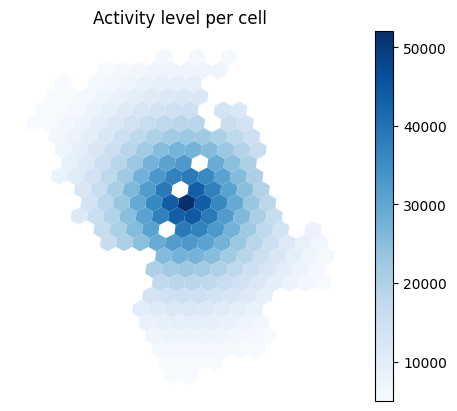

In [13]:
fig, ax = plt.subplots(1,1)
weighted_df_1.plot(
    ax=ax,
    column="weight",
    cmap = "Blues",
    legend=True
)
ax.set_axis_off()
ax.set_title("Activity level per cell");

In [14]:
def generate_trip_weight(weighted_df, scale=0.01, seed=154):
    random.seed(seed)

    all_nodes = weighted_df["cell_id"].tolist()
    pairs = list(combinations(all_nodes, 2))

    o_list = []
    d_list = []
    weights_list = []
    o_p_list = []
    d_p_list = []

    node_lookup = weighted_df.set_index("cell_id")

    for o, d in pairs:
        o_row = node_lookup.loc[o]
        d_row = node_lookup.loc[d]

        o_point = o_row["geometry"]
        d_point = d_row["geometry"]

        o_weight = o_row["weight"]
        d_weight = d_row["weight"]

        max_pair_weight = int((o_weight + d_weight) * scale)
        w = random.randint(0, max_pair_weight)

        o_list.append(o)
        d_list.append(d)
        weights_list.append(w)
        o_p_list.append(o_point)
        d_p_list.append(d_point)

    pair_df = pd.DataFrame({
        "o": o_list,
        "d": d_list,
        "weight": weights_list,
        "o-point": o_p_list,
        "d-point": d_p_list
    })

    return pair_df

In [17]:
pair_df = generate_trip_weight(weighted_df_1, scale=0.01, seed=154)

total_demand_1 = pair_df["weight"].sum()

In [19]:
# pair_df

In [20]:
# Parameters of GA algorithms
max_routes = 4
max_stops = 17
min_stops = 13
total_number_of_node = 44

total_kids = 10

In [21]:
def finding_neighbors(pointes_weighted, grid):
    weighted_grid = grid.copy()

    weighted_grid = weighted_grid.merge(
    pointes_weighted[['cell_id', 'weight']], on='cell_id', how='left')

    mytree = weighted_grid.sindex
    weighted_grid["vicinity"] = weighted_grid.apply(
        lambda x: weighted_grid.iloc[
            mytree.query(x.geometry, predicate="touches")
        ]["cell_id"].tolist(),
        axis=1
    )

    return weighted_grid

In [24]:
valid_connections = finding_neighbors(weighted_df_1, grid)

In [25]:
accepted_kids_new = []

while len(accepted_kids_new) < total_kids:
    all_routes = {}
    potential_start = weighted_df_1["cell_id"].tolist()

    routes = 1

    edge_list = {}

    while routes < max_routes + 1:
        if not potential_start:
            break

        route_current = []
        start_node = random.choice(potential_start)
        route_current.append(start_node)

        while len(route_current) < max_stops:
            curr_node = route_current[-1]

            if curr_node in potential_start:
                potential_start.remove(curr_node)

            # filter out nodes already in this route
            vicinity_current = valid_connections.loc[valid_connections.cell_id==curr_node, "vicinity"].values[0]
            poss_neighbors = [n for n in vicinity_current if n not in route_current]

            # dead-end handling
            if not poss_neighbors:
                if len(route_current) < min_stops:
                    route_current.reverse()
                    curr_node = route_current[-1]
                    vicinity_current = valid_connections.loc[valid_connections.cell_id==curr_node, "vicinity"].values[0]
                    poss_neighbors = [n for n in vicinity_current if n not in route_current]
                    if not poss_neighbors:
                        break
                else:
                    break


            neighbor_node = []
            neighbor_weights = []
        
            for i in poss_neighbors:
                neighbor_node.append(i)
                neighbor_weights.append(valid_connections.loc[valid_connections["cell_id"] == i, "weight"].iloc[0])

            next_node = random.choices(neighbor_node, weights=neighbor_weights, k=1)[0]

            route_current.append(next_node)

            if curr_node in edge_list:
                edge_list[curr_node].append(next_node)
            else:
                edge_list[curr_node] = [next_node]

        all_routes[routes] = route_current
        routes += 1

    ## Check if its one componet 
    G = nx.from_dict_of_lists(edge_list)
    is_one_component = nx.is_connected(G)
    ############################################# This section Anastassia #############################################
    if is_one_component:
        evaluation_score = 0
        temp_score = 0
        pairs = list(combinations(G.nodes(), 2))
        for (node1, node2) in pairs:
            pair_demand = pair_df.loc[
                ((pair_df["o"] == node1) | (pair_df["d"] == node1)) & ((pair_df["o"] == node2) | (pair_df["d"] == node2)),
                "weight"
            ].sum()
            temp_score += pair_demand

        evaluation_score = (temp_score / total_demand_1) * 100
    ###################################################################################################################

        all_routes["Score as %"] = evaluation_score
        all_routes["Number of edges"] = G.number_of_edges()
        accepted_kids_new.append(all_routes)
    else:
        continue

TypeError: 'Polygon' object is not iterable

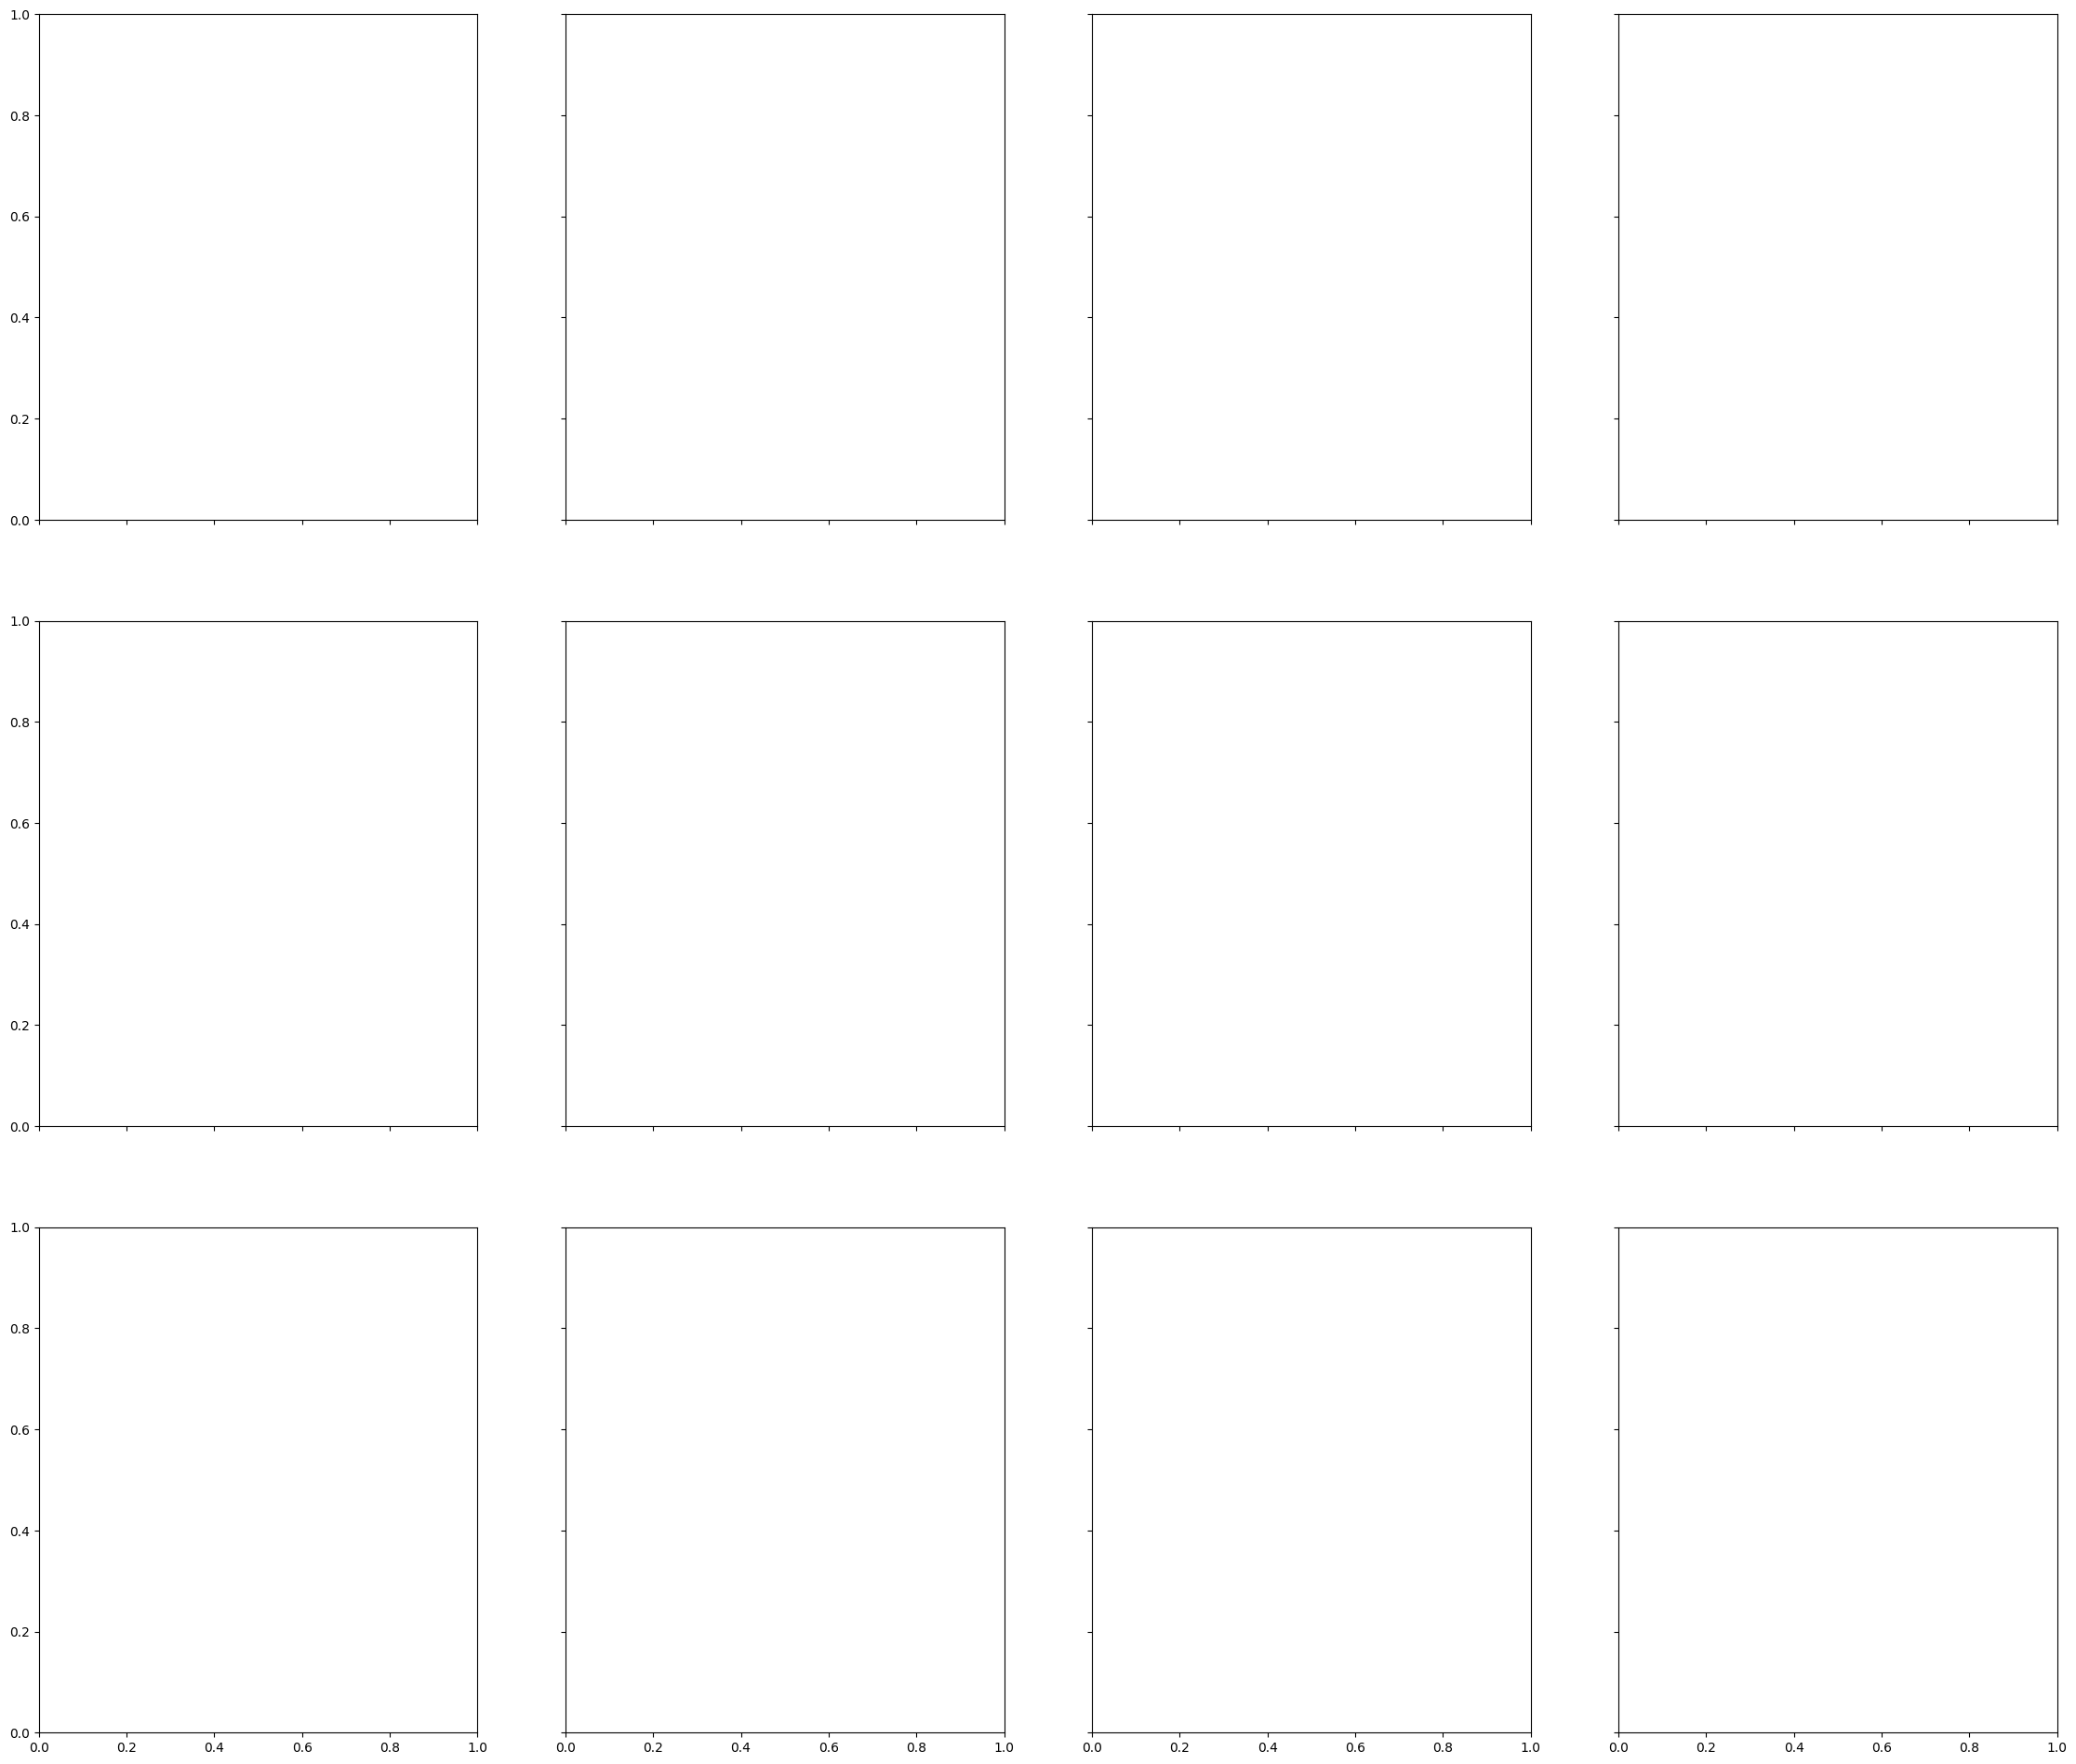

In [28]:
# -------- REPROJECT FOR PLOTTING --------
grid_plot = grid.to_crs(epsg=3857)
points_plot = weighted_df_1.to_crs(epsg=3857)

# -------- LINE CREATION --------
def create_line(p1_id, p2_id, gdf_stops):
    p1 = gdf_stops.loc[
        gdf_stops["cell_id"] == p1_id, "geometry"
    ].iloc[0]

    p2 = gdf_stops.loc[
        gdf_stops["cell_id"] == p2_id, "geometry"
    ].iloc[0]

    return LineString([p1, p2])


# -------- BUILD EDGES --------
def build_edges_gdf(solution_routes_dict, gdf_stops):
    records = []

    for route_id, route in solution_routes_dict.items():
        if not isinstance(route, (list, tuple)):
            continue

        if len(route) < 2:
            continue

        for k in range(len(route) - 1):
            p1 = route[k]
            p2 = route[k + 1]

            line = create_line(p1, p2, gdf_stops)

            records.append({
                "geometry": line,
                "route_id": route_id
            })

    return gpd.GeoDataFrame(records, geometry="geometry", crs=gdf_stops.crs)



# -------- MAIN PLOT --------
n = len(accepted_kids_new)
max_cols = 4

ncols = min(max_cols, n) if n > 0 else 1
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(7 * ncols, 8 * nrows),
    sharex=True,
    sharey=True
)

axes = np.atleast_1d(axes).ravel()

for idx, solution_dict in enumerate(accepted_kids_new):
    ax = axes[idx]

    score = solution_dict.get("Score as %", None)
    edges_gdf = build_edges_gdf(solution_dict, points_plot)

    used_nodes = []
    for k, v in solution_dict.items():
        if isinstance(v, (list, tuple)):
            used_nodes.extend(v)
    used_nodes = list(set(used_nodes))

    used_points = points_plot[
        points_plot["cell_id"].isin(used_nodes)
    ]

    used_hex = grid_plot[
        grid_plot["cell_id"].isin(used_nodes)
    ] if "cell_id" in grid_plot.columns else None

    # Set map extent to Copenhagen area
    ax.set_xlim(grid_plot.total_bounds[0], grid_plot.total_bounds[2])
    ax.set_ylim(grid_plot.total_bounds[1], grid_plot.total_bounds[3])

    # basemap first
    cx.add_basemap(
        ax=ax,
        source=cx.providers.CartoDB.Voyager,
        crs=grid_plot.crs
    )

    # full grid
    grid_plot.boundary.plot(
        ax=ax,
        color="gray",
        linewidth=0.4,
        alpha=0.5,
        zorder=2
    )

    # used hexagons
    if used_hex is not None and not used_hex.empty:
        used_hex.boundary.plot(
            ax=ax,
            color="black",
            linewidth=1.2,
            zorder=3
        )

    # route lines
    if not edges_gdf.empty:
        edges_gdf.plot(
            ax=ax,
            column="route_id",
            categorical=True,
            legend=False,
            linewidth=3,
            zorder=4
        )

    # all points
    points_plot.plot(
        ax=ax,
        color="lightgray",
        markersize=8,
        zorder=5
    )

    # used points
    if not used_points.empty:
        used_points.plot(
            ax=ax,
            color="blue",
            markersize=20,
            zorder=6
        )

    if isinstance(score, (int, float)):
        ax.set_title(f"Solution #{idx + 1}\nScore (%): {score:.3f}")
    elif score is not None:
        ax.set_title(f"Solution #{idx + 1}\nScore (%): {score}")
    else:
        ax.set_title(f"Solution #{idx + 1}")

    ax.set_axis_off()
    ax.set_aspect("equal")

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
